In [1]:
# Install the official OpenAI package if not already present
!pip install -q openai graphviz

In [2]:
import base64
import os
from io import BytesIO
from PIL import Image
import graphviz
from openai import OpenAI
from google.colab import userdata # Safe way to fetch secrets in Colab
import IPython.display as display

In [3]:
# Securely retrieve the API key from Colab Secrets
try:
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=OPENAI_API_KEY)
    print("✅ OpenAI Client initialized successfully!")
except Exception as e:
    print("❌ Error: Make sure you added OPENAI_API_KEY to your Colab Secrets tab.")

✅ OpenAI Client initialized successfully!


🖼️ ERD successfully drawn and saved as: complex_erd_schema.png


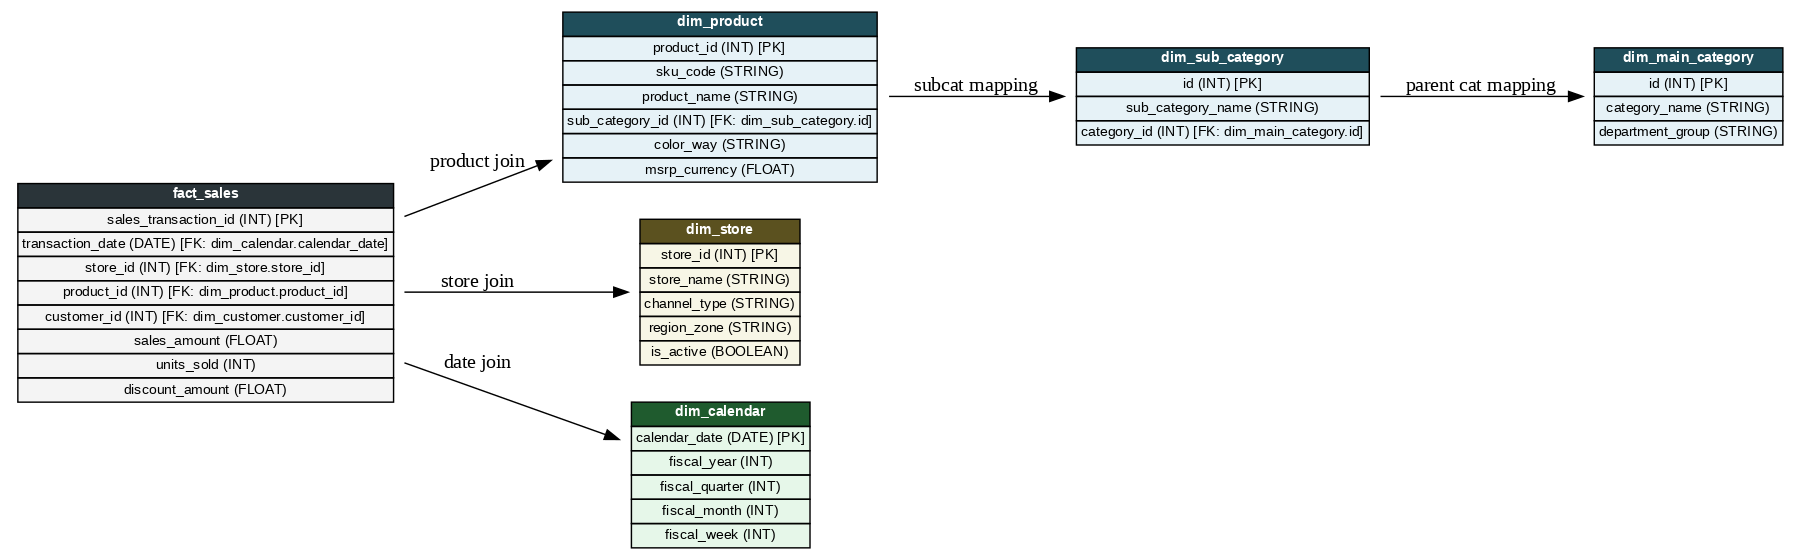

In [5]:
def generate_complex_erd():
    dot = graphviz.Digraph(comment='Complex Retail ERD', format='png')
    dot.attr(rankdir='LR', size='12,12', dpi='150')
    dot.attr('node', shape='none', fontname='Helvetica', fontsize='10')

    # Define tables using HTML labels to mimic realistic data warehouse structural schemas
    # Changed '->' to ':' to keep the HTML string compliant with Graphviz's strict HTML parser
    dot.node('fact_sales', '''<
        <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" BGCOLOR="#F4F4F4">
            <TR><TD BGCOLOR="#2A3439"><FONT COLOR="white"><B>fact_sales</B></FONT></TD></TR>
            <TR><TD PORT="f1">sales_transaction_id (INT) [PK]</TD></TR>
            <TR><TD PORT="f2">transaction_date (DATE) [FK: dim_calendar.calendar_date]</TD></TR>
            <TR><TD PORT="f3">store_id (INT) [FK: dim_store.store_id]</TD></TR>
            <TR><TD PORT="f4">product_id (INT) [FK: dim_product.product_id]</TD></TR>
            <TR><TD PORT="f5">customer_id (INT) [FK: dim_customer.customer_id]</TD></TR>
            <TR><TD>sales_amount (FLOAT)</TD></TR>
            <TR><TD>units_sold (INT)</TD></TR>
            <TR><TD>discount_amount (FLOAT)</TD></TR>
        </TABLE>
    >''')

    dot.node('dim_product', '''<
        <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" BGCOLOR="#E6F2F7">
            <TR><TD BGCOLOR="#1F4E5B"><FONT COLOR="white"><B>dim_product</B></FONT></TD></TR>
            <TR><TD PORT="p1">product_id (INT) [PK]</TD></TR>
            <TR><TD PORT="p2">sku_code (STRING)</TD></TR>
            <TR><TD>product_name (STRING)</TD></TR>
            <TR><TD PORT="p3">sub_category_id (INT) [FK: dim_sub_category.id]</TD></TR>
            <TR><TD>color_way (STRING)</TD></TR>
            <TR><TD>msrp_currency (FLOAT)</TD></TR>
        </TABLE>
    >''')

    dot.node('dim_sub_category', '''<
        <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" BGCOLOR="#E6F2F7">
            <TR><TD BGCOLOR="#1F4E5B"><FONT COLOR="white"><B>dim_sub_category</B></FONT></TD></TR>
            <TR><TD PORT="sc1">id (INT) [PK]</TD></TR>
            <TR><TD>sub_category_name (STRING)</TD></TR>
            <TR><TD PORT="sc2">category_id (INT) [FK: dim_main_category.id]</TD></TR>
        </TABLE>
    >''')

    dot.node('dim_main_category', '''<
        <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" BGCOLOR="#E6F2F7">
            <TR><TD BGCOLOR="#1F4E5B"><FONT COLOR="white"><B>dim_main_category</B></FONT></TD></TR>
            <TR><TD PORT="c1">id (INT) [PK]</TD></TR>
            <TR><TD>category_name (STRING)</TD></TR>
            <TR><TD>department_group (STRING)</TD></TR>
        </TABLE>
    >''')

    dot.node('dim_store', '''<
        <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" BGCOLOR="#F7F6E6">
            <TR><TD BGCOLOR="#5B511F"><FONT COLOR="white"><B>dim_store</B></FONT></TD></TR>
            <TR><TD PORT="s1">store_id (INT) [PK]</TD></TR>
            <TR><TD>store_name (STRING)</TD></TR>
            <TR><TD>channel_type (STRING)</TD></TR>
            <TR><TD>region_zone (STRING)</TD></TR>
            <TR><TD>is_active (BOOLEAN)</TD></TR>
        </TABLE>
    >''')

    dot.node('dim_calendar', '''<
        <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" BGCOLOR="#E6F7E9">
            <TR><TD BGCOLOR="#1F5B2E"><FONT COLOR="white"><B>dim_calendar</B></FONT></TD></TR>
            <TR><TD PORT="cal1">calendar_date (DATE) [PK]</TD></TR>
            <TR><TD>fiscal_year (INT)</TD></TR>
            <TR><TD>fiscal_quarter (INT)</TD></TR>
            <TR><TD>fiscal_month (INT)</TD></TR>
            <TR><TD>fiscal_week (INT)</TD></TR>
        </TABLE>
    >''')

    # Utilizing tail_port and head_port parameters explicitly avoids string quoting issues
    dot.edge('fact_sales', 'dim_calendar', tail_port='f2', head_port='cal1', label='date join')
    dot.edge('fact_sales', 'dim_store', tail_port='f3', head_port='s1', label='store join')
    dot.edge('fact_sales', 'dim_product', tail_port='f4', head_port='p1', label='product join')
    dot.edge('dim_product', 'dim_sub_category', tail_port='p3', head_port='sc1', label='subcat mapping')
    dot.edge('dim_sub_category', 'dim_main_category', tail_port='sc2', head_port='c1', label='parent cat mapping')

    # Render image layout cleanly inside workspace assets directory
    output_path = 'complex_erd_schema'
    dot.render(output_path, cleanup=True)
    return f"{output_path}.png"

# Generate the asset file path
image_filename = generate_complex_erd()
print(f"🖼️ ERD successfully drawn and saved as: {image_filename}")

# View the image right inside your Colab output window to verify layout complexity
import IPython.display as display
display.display(display.Image(filename=image_filename))

In [6]:
def run_pixel_rag_test(image_path: str, user_question: str):
    # 1. Encode the generated ERD image into an OpenAI-compatible Base64 format string
    with open(image_path, "rb") as img_file:
        base64_image = base64.b64encode(img_file.read()).decode('utf-8')

    print("🚀 Sending image and query payload to GPT-4o...")

    # 2. Invoke the vision model pass execution thread
    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are an expert Data Architecture Engineer. Your sole task is to analyze the provided ER Diagram "
                        "image, read its column keys, discover relationships, and output completely valid BigQuery Standard SQL "
                        "queries based exclusively on the image structures. Always fully qualify your table names."
                    )
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": user_question},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/png;base64,{base64_image}",
                                "detail": "high" # Enforces high-density scan matrix over tiny text details
                            }
                        }
                    ]
                }
            ],
            max_tokens=1000,
            temperature=0.0 # Force absolute zero deterministic reasoning response paths
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Execution failure: {str(e)}"

# Define a complex query requiring an implicit 4-table JOIN map through the diagram
question = (
    "I need a Standard SQL query that calculates the total sales_amount and total units_sold "
    "broken down by 'category_name' and 'channel_type' for the current fiscal_year = 2026. "
    "Inspect the ER diagram image to trace how to join fact_sales all the way up to dim_main_category "
    "step by step. Output the SQL and briefly point out the keys you detected to prove accuracy."
)

# Run the pipeline execution turn
evaluation_output = run_pixel_rag_test(image_filename, question)
print("\n--- 📊 PIXEL RAG ACCURACY REPORT OUTCOME ---")
print(evaluation_output)

🚀 Sending image and query payload to GPT-4o...

--- 📊 PIXEL RAG ACCURACY REPORT OUTCOME ---
To calculate the total `sales_amount` and total `units_sold` broken down by `category_name` and `channel_type` for the fiscal year 2026, we need to join several tables based on their relationships. Here's the step-by-step breakdown and the SQL query:

### Keys and Relationships:
1. **fact_sales** to **dim_calendar**: `fact_sales.transaction_date` = `dim_calendar.calendar_date`
2. **fact_sales** to **dim_store**: `fact_sales.store_id` = `dim_store.store_id`
3. **fact_sales** to **dim_product**: `fact_sales.product_id` = `dim_product.product_id`
4. **dim_product** to **dim_sub_category**: `dim_product.sub_category_id` = `dim_sub_category.id`
5. **dim_sub_category** to **dim_main_category**: `dim_sub_category.category_id` = `dim_main_category.id`

### SQL Query:
```sql
SELECT 
    dim_main_category.category_name,
    dim_store.channel_type,
    SUM(fact_sales.sales_amount) AS total_sales_amount,
  